Loading base layers...
  ✅ Rasters loaded
Building land mask...
  Land pixels: 419,979 of 3,200,000
  ✅ Masks applied

Generating Map 1: National Suitability Map...


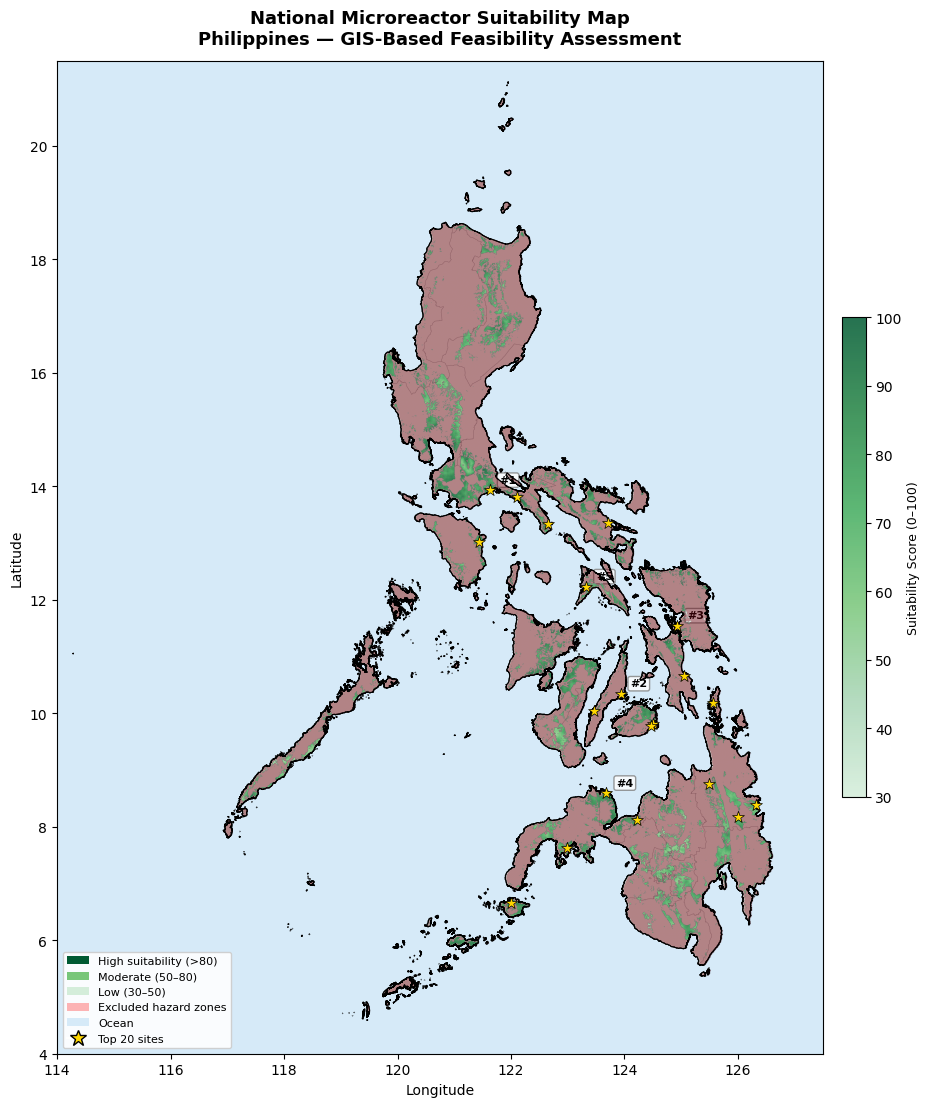

  ✅ Saved: map1_suitability.png

Generating Map 2: Cluster Archetype Map...


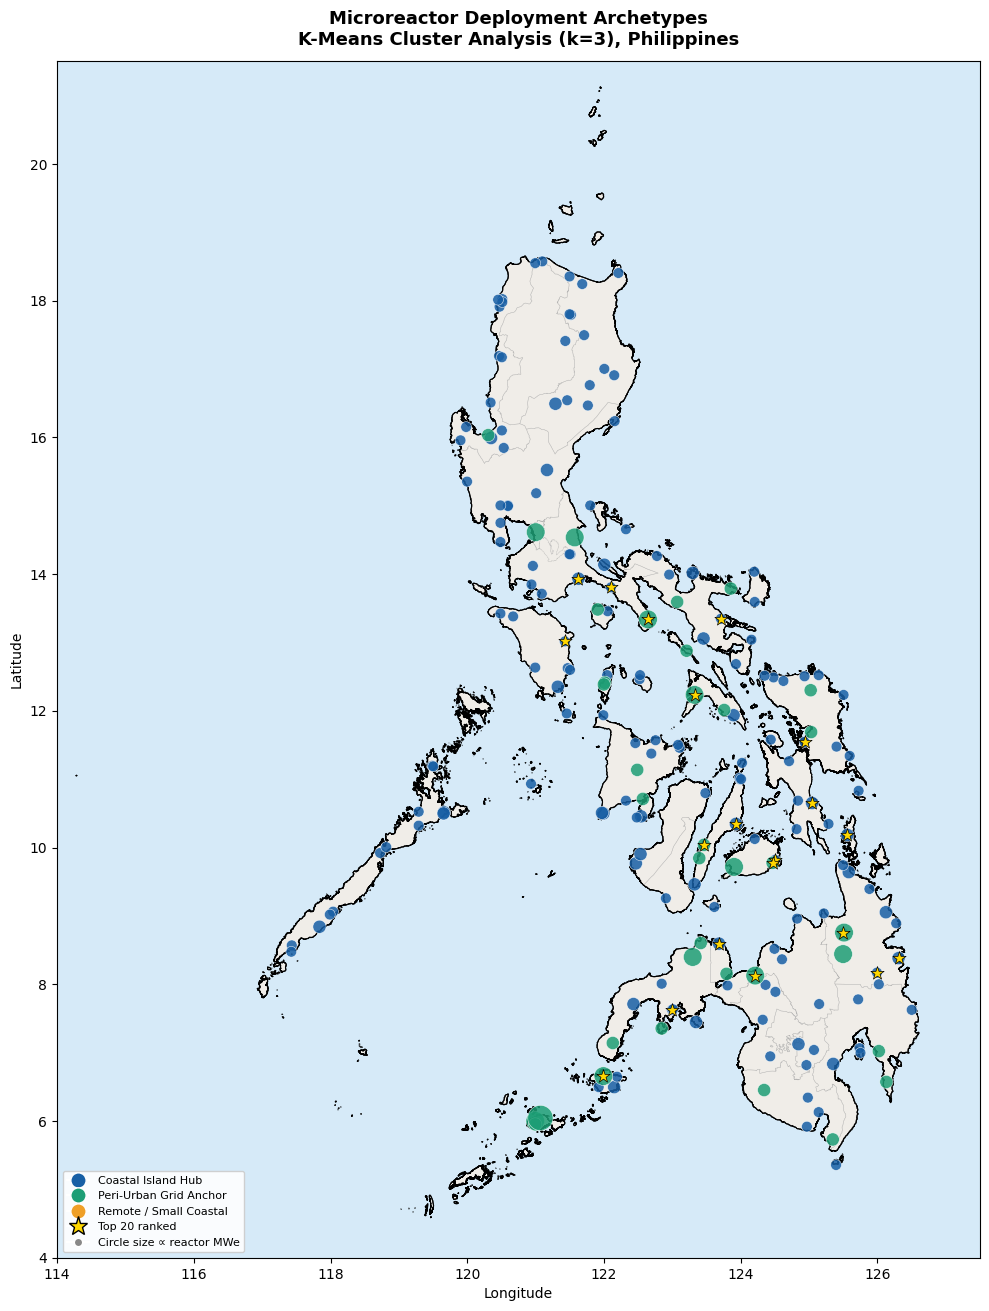

  ✅ Saved: map2_archetypes.png

Generating Map 3: Energy Coverage Ratio Map...


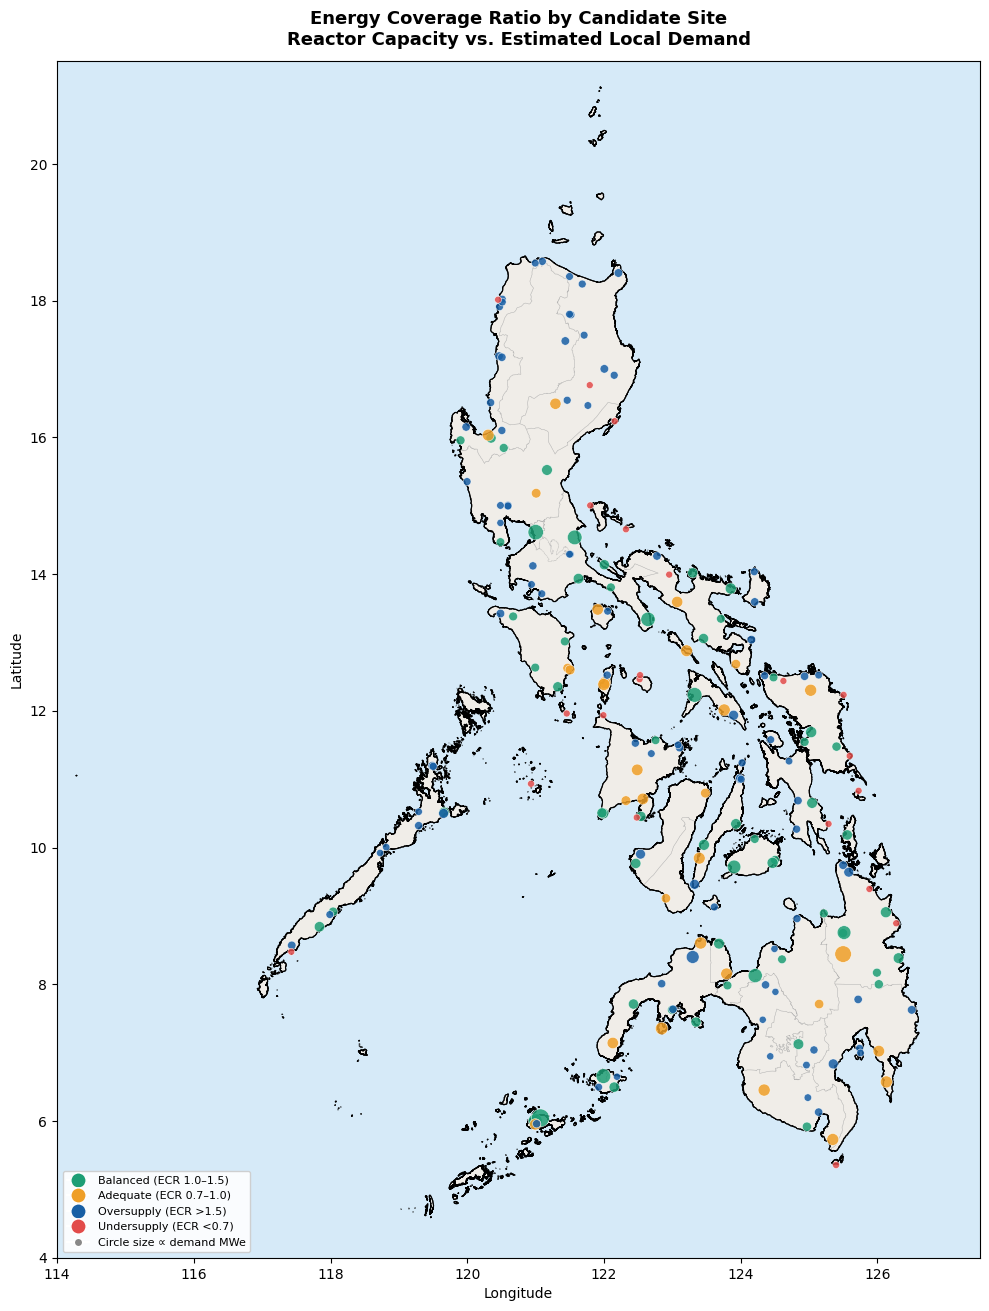

  ✅ Saved: map3_ecr.png

Generating Map 4: RF Classification Map...


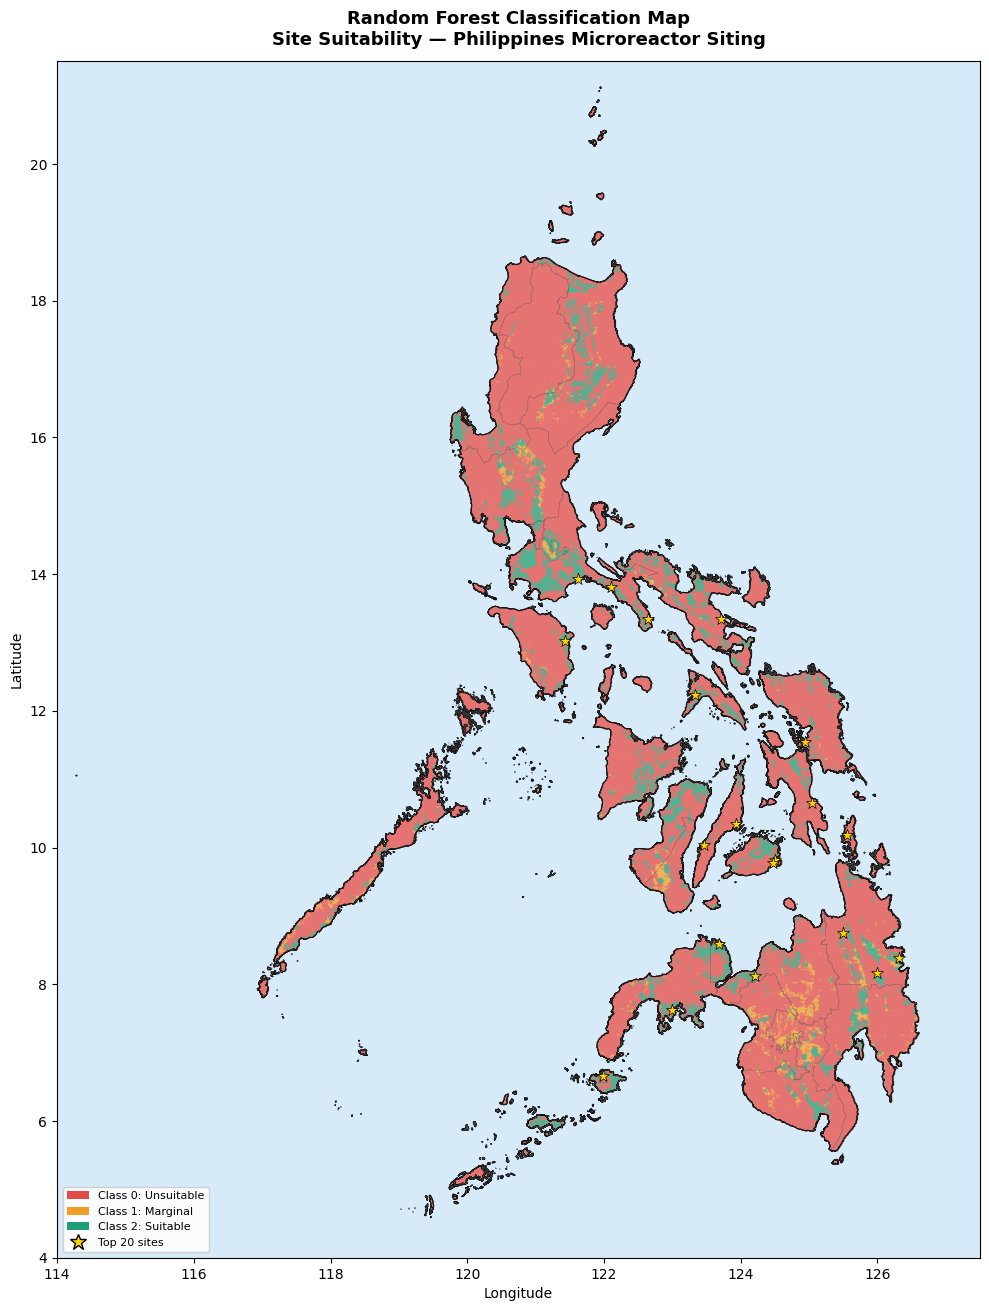

  ✅ Saved: map4_rf_classification.png

Generating Map 5: Top 20 Sites Detail...


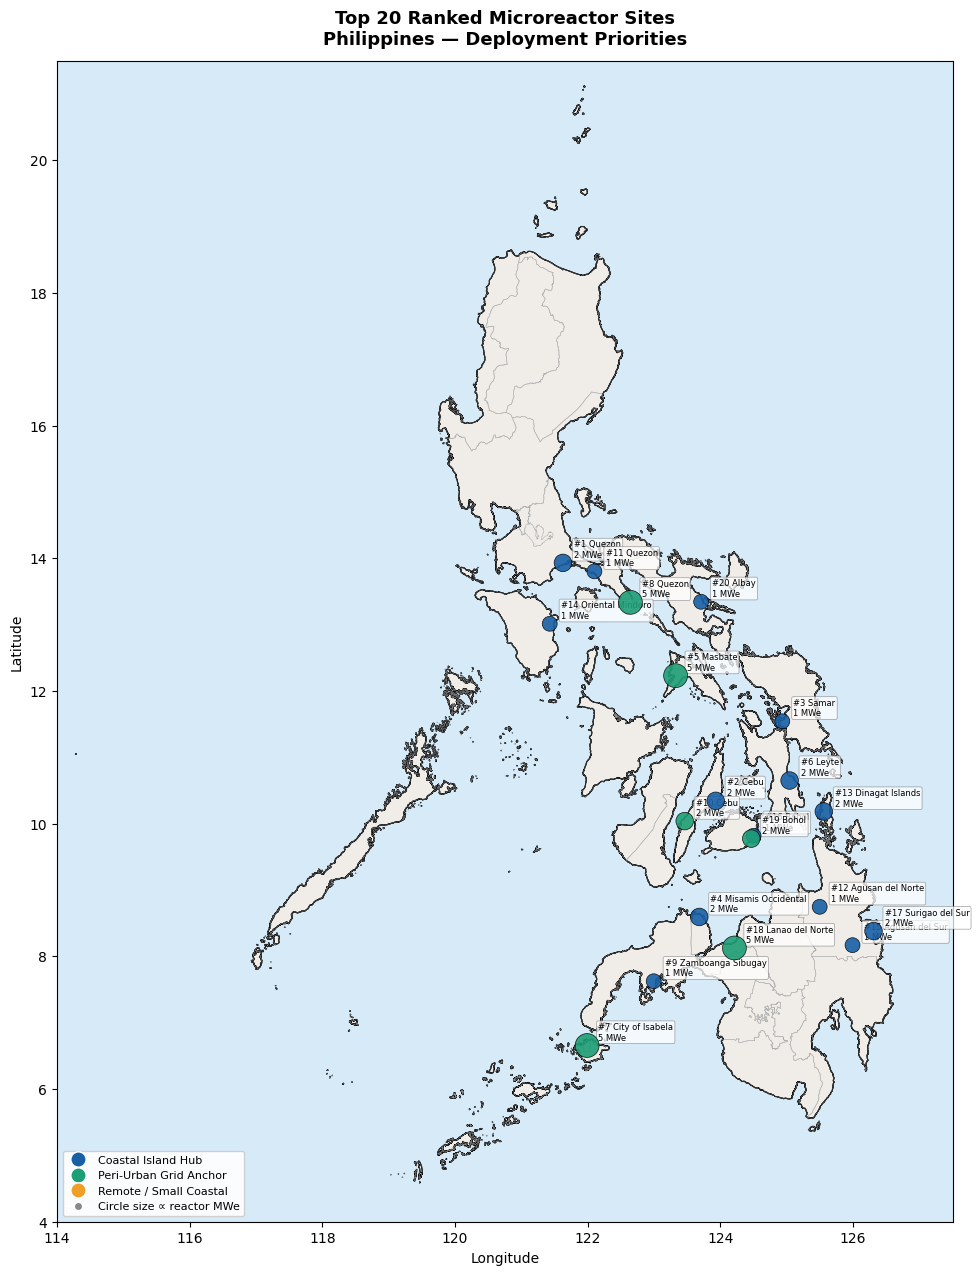

  ✅ Saved: map5_top20.png

✅ All 5 maps complete
Saved to: C:\Users\ailene.nunez\Downloads\microreactor_siting\figures


In [1]:
# ═══════════════════════════════════════════════════════════
# Notebook 07 — Map Visualizations (Fixed)
# Microreactor Siting — Philippines
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.features import rasterize as rio_rasterize
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.lines import Line2D
import os

PROCESSED = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\data\processed"
FIGURES   = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\figures"
RAW       = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\data\raw"
os.makedirs(FIGURES, exist_ok=True)

TARGET_H, TARGET_W = 2000, 1600

# ═══════════════════════════════════════════════════════════
# SECTION 1 — Load all base layers
# ═══════════════════════════════════════════════════════════

print("Loading base layers...")

phl0 = gpd.read_file(
    f"{RAW}/phl_adm_psa_namria_20231106_shp/"
    f"phl_admbnda_adm0_singlepart_psa_namria_20231106.shp"
)
phl1 = gpd.read_file(
    f"{RAW}/phl_adm_psa_namria_20231106_shp/"
    f"phl_admbnda_adm1_psa_namria_20231106.shp"
)

sites = gpd.read_file(f"{PROCESSED}/sites_clustered_ranked.gpkg")
top20 = sites[sites["final_rank"] <= 20].copy()

def load_1km(path):
    with rasterio.open(path) as src:
        data = src.read(
            1,
            out_shape=(TARGET_H, TARGET_W),
            resampling=Resampling.bilinear
        ).astype(np.float32)
        bounds = src.bounds
        transform = src.transform
    return data, bounds, transform

suitability, suit_bounds, suit_transform = load_1km(f"{PROCESSED}/suitability_1km.tif")
exclusion,   excl_bounds, excl_transform = load_1km(f"{PROCESSED}/master_exclusion_mask.tif")
rf_class,    rf_bounds,   rf_transform   = load_1km(f"{PROCESSED}/rf_classification.tif")

print("  ✅ Rasters loaded")

# ── Build land mask at 1km resolution ─────────────────────
print("Building land mask...")
phl0_4326   = phl0.to_crs(epsg=4326)
land_shapes = [(geom, 1) for geom in phl0_4326.geometry if geom is not None]
land_mask   = rio_rasterize(
    land_shapes,
    out_shape=(TARGET_H, TARGET_W),
    transform=suit_transform,
    fill=0,
    dtype=np.uint8
)
print(f"  Land pixels: {land_mask.sum():,} of {TARGET_H*TARGET_W:,}")

# ── Pre-masked arrays ──────────────────────────────────────
suit_plot = suitability.copy()
suit_plot[land_mask == 0]  = np.nan   # mask ocean
suit_plot[exclusion > 0.5] = np.nan   # mask excluded hazard zones

excl_plot = exclusion.copy().astype(float)
excl_plot[land_mask == 0]  = np.nan   # ocean transparent
excl_plot[exclusion < 0.5] = np.nan   # only show excluded

rf_plot = rf_class.copy().astype(float)
rf_plot[land_mask == 0] = np.nan

print("  ✅ Masks applied")

# ── Shared helpers ─────────────────────────────────────────
PHL_EXTENT = [114.0, 127.5, 4.0, 21.5]

def set_phl_extent(ax):
    ax.set_xlim(PHL_EXTENT[0], PHL_EXTENT[1])
    ax.set_ylim(PHL_EXTENT[2], PHL_EXTENT[3])
    ax.set_aspect("equal")

def draw_basemap(ax):
    """Draw ocean background + land fill + admin boundaries."""
    ax.set_facecolor("#d6eaf8")                                    # ocean blue
    phl0.plot(ax=ax, color="#f0ede8", edgecolor="black",
              linewidth=0.8, zorder=1)                             # land
    phl1.boundary.plot(ax=ax, color="#aaaaaa",
                       linewidth=0.3, alpha=0.6, zorder=2)        # province lines

archetype_colors = {
    "Coastal Island Hub":          "#185FA5",
    "Peri-Urban Grid Anchor":      "#1D9E75",
    "Remote Archipelago Endpoint": "#EF9F27",
    "Small Coastal Communities":   "#EF9F27",
}

# ═══════════════════════════════════════════════════════════
# MAP 1 — National Suitability Map
# ═══════════════════════════════════════════════════════════

print("\nGenerating Map 1: National Suitability Map...")

colors_suit = ["#d4edda", "#a8d5b5", "#78c679",
               "#41ab5d", "#238443", "#005a32"]
cmap_suit   = LinearSegmentedColormap.from_list("suit", colors_suit)

fig, ax = plt.subplots(figsize=(10, 14))
draw_basemap(ax)

# Suitability raster (land only)
im = ax.imshow(
    np.ma.masked_invalid(suit_plot),
    extent=[suit_bounds.left, suit_bounds.right,
            suit_bounds.bottom, suit_bounds.top],
    cmap=cmap_suit,
    vmin=30, vmax=100,
    alpha=0.85,
    origin="upper",
    zorder=3
)

# Exclusion overlay (land only, stronger red)
ax.imshow(
    np.ma.masked_invalid(excl_plot),
    extent=[excl_bounds.left, excl_bounds.right,
            excl_bounds.bottom, excl_bounds.top],
    cmap=plt.cm.Reds,
    vmin=0, vmax=1,
    alpha=0.45,
    origin="upper",
    zorder=4
)

# Admin boundary on top
phl0.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)

# Top 20 stars
top20.plot(
    ax=ax,
    color="gold",
    edgecolor="black",
    linewidth=0.5,
    markersize=80,
    marker="*",
    zorder=6
)

# Label top 5
for _, row in top20[top20["final_rank"] <= 5].iterrows():
    ax.annotate(
        f"#{row['final_rank']}",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(7, 5), textcoords="offset points",
        fontsize=8, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="gray")
    )

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.35, pad=0.02)
cbar.set_label("Suitability Score (0–100)", fontsize=9)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#005a32", label="High suitability (>80)"),
    mpatches.Patch(facecolor="#78c679", label="Moderate (50–80)"),
    mpatches.Patch(facecolor="#d4edda", label="Low (30–50)"),
    mpatches.Patch(facecolor="#FF6B6B", alpha=0.5, label="Excluded hazard zones"),
    mpatches.Patch(facecolor="#d6eaf8", label="Ocean"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",
           markeredgecolor="black", markersize=12, label="Top 20 sites"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=8,
          framealpha=0.9)

set_phl_extent(ax)
ax.set_title(
    "National Microreactor Suitability Map\n"
    "Philippines — GIS-Based Feasibility Assessment",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{FIGURES}/map1_suitability.png", dpi=300, bbox_inches="tight")
plt.show()
print("  ✅ Saved: map1_suitability.png")

# ═══════════════════════════════════════════════════════════
# MAP 2 — Cluster Archetype Map
# ═══════════════════════════════════════════════════════════

print("\nGenerating Map 2: Cluster Archetype Map...")

fig, ax = plt.subplots(figsize=(10, 14))
draw_basemap(ax)
phl0.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=3)

for archetype, color in archetype_colors.items():
    subset = sites[sites["archetype"] == archetype]
    if len(subset) == 0:
        continue
    sizes = subset["reactor_mwe"].values * 30 + 30
    subset.plot(
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.4,
        markersize=sizes,
        alpha=0.85,
        zorder=4
    )

# Top 20 stars
top20.plot(
    ax=ax,
    color="gold",
    edgecolor="black",
    linewidth=0.5,
    markersize=100,
    marker="*",
    zorder=5
)

legend_elements = [
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#185FA5", markersize=11,
           label="Coastal Island Hub"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#1D9E75", markersize=11,
           label="Peri-Urban Grid Anchor"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#EF9F27", markersize=11,
           label="Remote / Small Coastal"),
    Line2D([0],[0], marker="*", color="w",
           markerfacecolor="gold", markeredgecolor="black",
           markersize=14, label="Top 20 ranked"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#888888", markersize=6,
           label="Circle size ∝ reactor MWe"),
]
ax.legend(handles=legend_elements, loc="lower left",
          fontsize=8, framealpha=0.9)

set_phl_extent(ax)
ax.set_title(
    "Microreactor Deployment Archetypes\n"
    "K-Means Cluster Analysis (k=3), Philippines",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{FIGURES}/map2_archetypes.png", dpi=300, bbox_inches="tight")
plt.show()
print("  ✅ Saved: map2_archetypes.png")

# ═══════════════════════════════════════════════════════════
# MAP 3 — Energy Coverage Ratio Map
# ═══════════════════════════════════════════════════════════

print("\nGenerating Map 3: Energy Coverage Ratio Map...")

ecr_colors = {
    "Balanced":    "#1D9E75",
    "Adequate":    "#EF9F27",
    "Oversupply":  "#185FA5",
    "Undersupply": "#E24B4A",
}

fig, ax = plt.subplots(figsize=(10, 14))
draw_basemap(ax)
phl0.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=3)

for cat, color in ecr_colors.items():
    subset = sites[sites["ecr_category"] == cat]
    if len(subset) == 0:
        continue
    sizes = np.clip(subset["demand_mwe"].values * 20 + 25, 25, 200)
    subset.plot(
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.4,
        markersize=sizes,
        alpha=0.85,
        zorder=4
    )

legend_elements = [
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#1D9E75", markersize=11,
           label="Balanced (ECR 1.0–1.5)"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#EF9F27", markersize=11,
           label="Adequate (ECR 0.7–1.0)"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#185FA5", markersize=11,
           label="Oversupply (ECR >1.5)"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#E24B4A", markersize=11,
           label="Undersupply (ECR <0.7)"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#888888", markersize=6,
           label="Circle size ∝ demand MWe"),
]
ax.legend(handles=legend_elements, loc="lower left",
          fontsize=8, framealpha=0.9)

set_phl_extent(ax)
ax.set_title(
    "Energy Coverage Ratio by Candidate Site\n"
    "Reactor Capacity vs. Estimated Local Demand",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{FIGURES}/map3_ecr.png", dpi=300, bbox_inches="tight")
plt.show()
print("  ✅ Saved: map3_ecr.png")

# ═══════════════════════════════════════════════════════════
# MAP 4 — RF Classification Map
# ═══════════════════════════════════════════════════════════

print("\nGenerating Map 4: RF Classification Map...")

cmap_rf = ListedColormap(["#E24B4A", "#EF9F27", "#1D9E75"])

fig, ax = plt.subplots(figsize=(10, 14))
draw_basemap(ax)

ax.imshow(
    np.ma.masked_invalid(rf_plot),
    extent=[rf_bounds.left, rf_bounds.right,
            rf_bounds.bottom, rf_bounds.top],
    cmap=cmap_rf,
    vmin=0, vmax=2,
    alpha=0.75,
    origin="upper",
    zorder=3
)

phl0.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=4)
phl1.boundary.plot(ax=ax, color="#666666", linewidth=0.3,
                   alpha=0.5, zorder=4)

top20.plot(
    ax=ax,
    color="gold",
    edgecolor="black",
    linewidth=0.5,
    markersize=80,
    marker="*",
    zorder=5
)

legend_elements = [
    mpatches.Patch(facecolor="#E24B4A",
                   label="Class 0: Unsuitable"),
    mpatches.Patch(facecolor="#EF9F27",
                   label="Class 1: Marginal"),
    mpatches.Patch(facecolor="#1D9E75",
                   label="Class 2: Suitable"),
    Line2D([0],[0], marker="*", color="w",
           markerfacecolor="gold", markeredgecolor="black",
           markersize=12, label="Top 20 sites"),
]
ax.legend(handles=legend_elements, loc="lower left",
          fontsize=8, framealpha=0.9)

set_phl_extent(ax)
ax.set_title(
    "Random Forest Classification Map\n"
    "Site Suitability — Philippines Microreactor Siting",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{FIGURES}/map4_rf_classification.png", dpi=300, bbox_inches="tight")
plt.show()
print("  ✅ Saved: map4_rf_classification.png")

# ═══════════════════════════════════════════════════════════
# MAP 5 — Top 20 Sites Detail Map
# ═══════════════════════════════════════════════════════════

print("\nGenerating Map 5: Top 20 Sites Detail...")

fig, ax = plt.subplots(figsize=(10, 14))
draw_basemap(ax)
phl0.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=3)
phl1.boundary.plot(ax=ax, color="#aaaaaa", linewidth=0.3,
                   alpha=0.6, zorder=3)

for archetype, color in archetype_colors.items():
    subset = top20[top20["archetype"] == archetype]
    if len(subset) == 0:
        continue
    sizes = subset["reactor_mwe"].values * 45 + 70
    subset.plot(
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        markersize=sizes,
        alpha=0.9,
        zorder=4
    )

# Label all top 20
for _, row in top20.iterrows():
    prov  = str(row.get("province", "")).split("(")[0].strip()
    label = f"#{row['final_rank']} {prov}\n{row['reactor_mwe']} MWe"
    ax.annotate(
        label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(8, 4), textcoords="offset points",
        fontsize=6,
        bbox=dict(boxstyle="round,pad=0.2", fc="white",
                  alpha=0.75, ec="gray", lw=0.5)
    )

legend_elements = [
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#185FA5", markersize=11,
           label="Coastal Island Hub"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#1D9E75", markersize=11,
           label="Peri-Urban Grid Anchor"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#EF9F27", markersize=11,
           label="Remote / Small Coastal"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#888888", markersize=6,
           label="Circle size ∝ reactor MWe"),
]
ax.legend(handles=legend_elements, loc="lower left",
          fontsize=8, framealpha=0.9)

set_phl_extent(ax)
ax.set_title(
    "Top 20 Ranked Microreactor Sites\n"
    "Philippines — Deployment Priorities",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{FIGURES}/map5_top20.png", dpi=300, bbox_inches="tight")
plt.show()
print("  ✅ Saved: map5_top20.png")

print("\n✅ All 5 maps complete")
print(f"Saved to: {FIGURES}")